# Charity Register Data Analysis


In [1]:
from pathlib import Path
import sys

# Find the repository when Jupyter starts in the notebook directory.
PROJECT_ROOT = next(
    directory for directory in (Path.cwd(), *Path.cwd().parents)
    if (directory / "pyproject.toml").is_file()
    and (directory / "projects" / "council_asset_sales").is_dir()
)
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.seasonal import STL

from uk_charity_local_authority_analysis.charity_commission_register.build_charity_register import (
    CATEGORY_MAPPING,
    latest_charity_register,
)
from projects.council_asset_sales import config, filepath

# Load the charity register copy prepared for council_asset_sales,
# following the same selection logic as the council panel build.
# Use only the charity register copies selected for this project.
charity_path = (
    filepath.CHARITY_REGISTER_FILEPATH
    if filepath.CHARITY_REGISTER_FILEPATH is not None
    else latest_charity_register(filepath.CHARITY_REGISTER_BASE_FILEPATH)
)
charity = pl.read_parquet(charity_path)
print(f"Loaded {charity.height:,} charities from {charity_path}")

Loaded 351,959 charities from C:\Users\User\codespace\uk-charity-local-authority-analysis\projects\council_asset_sales\datasets\charity_register_inputs\charity_register_20260913_175440_382682Z.parquet


## 1. Active Charities
This will show the number of active charities each month from 2015 to 2024.


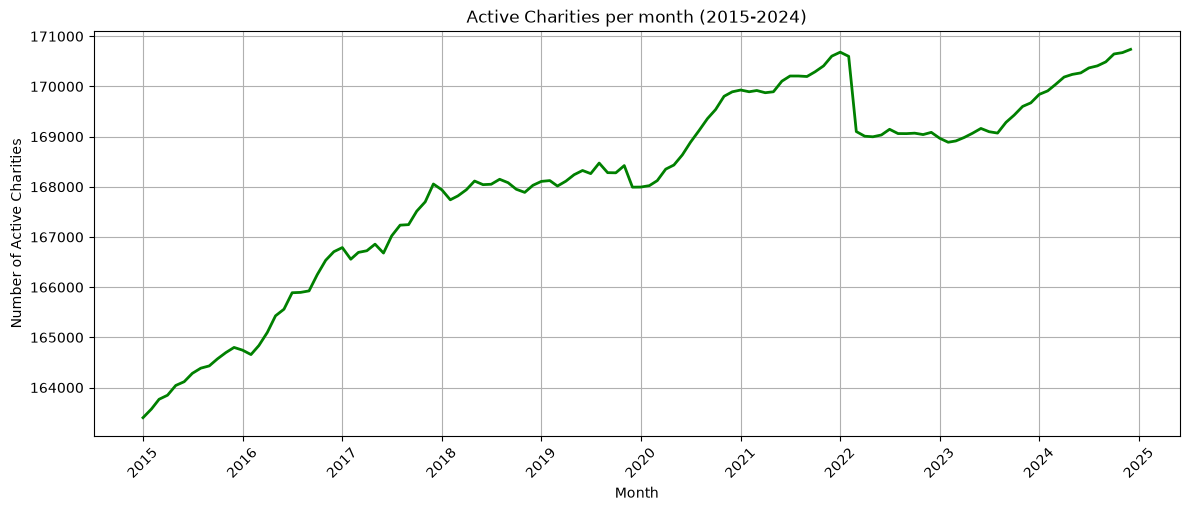

In [2]:
def plot_active_charities(charity: pl.DataFrame):
    starts = list(pd.date_range("2015-01-01", "2024-12-01", freq="MS").date)
    months_df = pl.DataFrame({"month": starts}, schema={"month": pl.Date})

    df = charity.select(
        [
            pl.col("date_of_registration").dt.truncate("1mo").alias("reg_month"),
            pl.col("date_of_removal").dt.truncate("1mo").alias("rem_month"),
        ]
    )

    # Calculate using fast cross join instead of python loop
    population_df = (
        df.join(months_df, how="cross")
        .filter(
            (pl.col("reg_month") <= pl.col("month"))
            & (pl.col("rem_month").is_null() | (pl.col("rem_month") > pl.col("month")))
        )
        .group_by("month")
        .agg(pl.len().alias("active"))
        .to_pandas()
        .set_index("month")
        .sort_index()
    )

    plt.figure(figsize=(12, 5))
    plt.plot(
        pd.to_datetime(population_df.index),
        population_df["active"],
        linewidth=2,
        color="green",
    )
    plt.title("Active Charities per month (2015-2024)")
    plt.xlabel("Month")
    plt.ylabel("Number of Active Charities")
    plt.grid(True)
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()


plot_active_charities(charity)

## 2. Monthly Charity Registration and Removal Rates
This will show the monthly registration and removal rates as a percentage of the previous month's active charities.


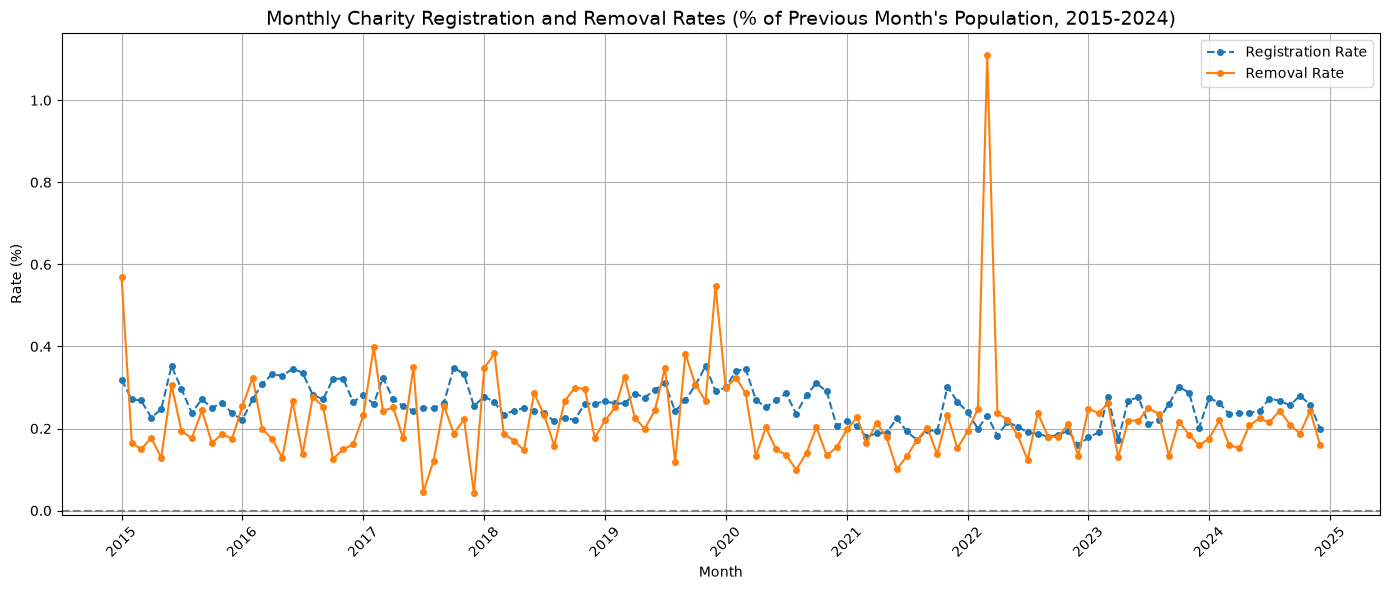

In [3]:
def plot_charity_rates(charity: pl.DataFrame):
    starts = list(pd.date_range("2014-12-01", "2024-12-01", freq="MS").date)
    months_df = pl.DataFrame({"month": starts}, schema={"month": pl.Date})

    df = charity.select(
        [
            pl.col("date_of_registration").dt.truncate("1mo").alias("reg_month"),
            pl.col("date_of_removal").dt.truncate("1mo").alias("rem_month"),
        ]
    )

    active_counts = (
        df.join(months_df, how="cross")
        .filter(
            (pl.col("reg_month") <= pl.col("month"))
            & (pl.col("rem_month").is_null() | (pl.col("rem_month") > pl.col("month")))
        )
        .group_by("month")
        .agg(pl.len().alias("active"))
        .to_pandas()
        .set_index("month")
    )

    reg_counts = (
        df.filter(pl.col("reg_month").is_in(starts))
        .group_by("reg_month")
        .agg(pl.len().alias("registered"))
        .to_pandas()
        .set_index("reg_month")
        .reindex(starts, fill_value=0)
    )

    rem_counts = (
        df.filter(pl.col("rem_month").is_in(starts))
        .group_by("rem_month")
        .agg(pl.len().alias("removed"))
        .to_pandas()
        .set_index("rem_month")
        .reindex(starts, fill_value=0)
    )

    counts_df = pd.DataFrame(index=starts)
    counts_df["active"] = active_counts["active"]
    counts_df["registered"] = reg_counts["registered"]
    counts_df["removed"] = rem_counts["removed"]
    counts_df = counts_df.fillna(0)

    counts_df["prev_active"] = counts_df["active"].shift(1)
    counts_df["registration_rate"] = (
        counts_df["registered"] / counts_df["prev_active"]
    ) * 100
    counts_df["removal_rate"] = (counts_df["removed"] / counts_df["prev_active"]) * 100

    plot_df = counts_df.loc[counts_df.index >= pd.Timestamp("2015-01-01").date()]

    plt.figure(figsize=(14, 6))
    plt.plot(
        pd.to_datetime(plot_df.index),
        plot_df["registration_rate"],
        linestyle="--",
        marker="o",
        markersize=4,
        label="Registration Rate",
    )
    plt.plot(
        pd.to_datetime(plot_df.index),
        plot_df["removal_rate"],
        linestyle="-",
        marker="o",
        markersize=4,
        label="Removal Rate",
    )
    plt.title(
        "Monthly Charity Registration and Removal Rates (% of Previous Month's Population, 2015-2024)",
        fontsize=14,
    )
    plt.xlabel("Month")
    plt.ylabel("Rate (%)")
    plt.grid(True)
    plt.legend()
    plt.axhline(0, color="grey", linestyle="--")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_charity_rates(charity)

## 3. Registrations and Removals per Financial Year
This will show the number of registrations and removals each year from 2015 to 2023.


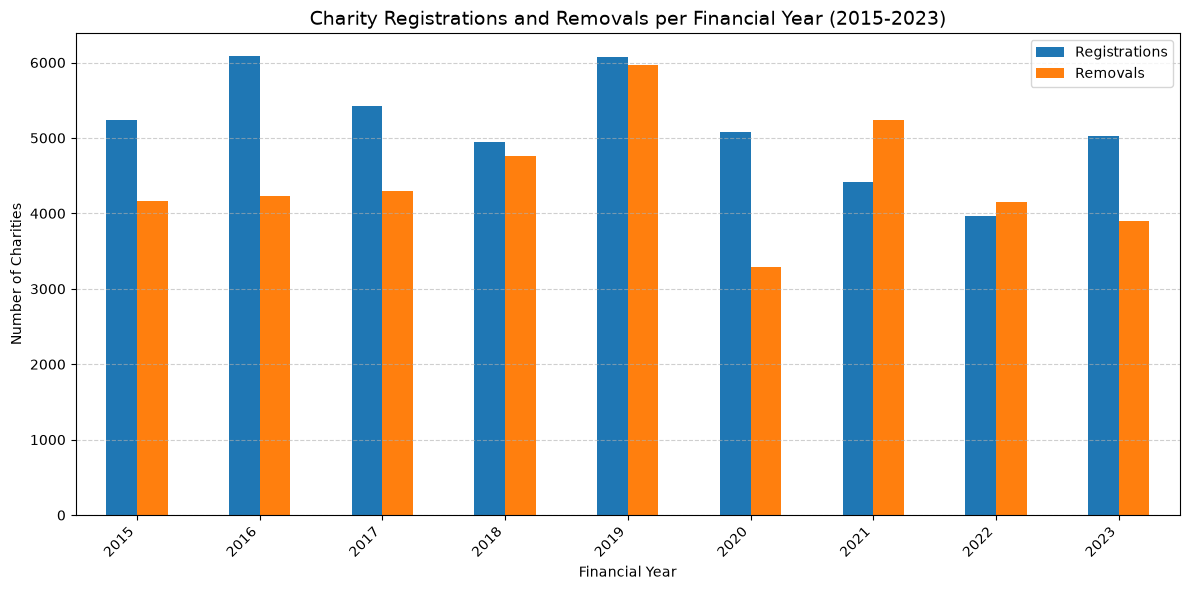

In [4]:
def plot_registrations_removals_bar(
    charity: pl.DataFrame, start_year: int = 2015, end_year: int = 2023
):
    reg_counts = (
        charity.filter(pl.col("registration_fy").is_not_null())
        .group_by(pl.col("registration_fy").alias("financial_year"))
        .agg(pl.len().alias("registered"))
    )

    rem_counts = (
        charity.filter(pl.col("removal_fy").is_not_null())
        .group_by(pl.col("removal_fy").alias("financial_year"))
        .agg(pl.len().alias("removed"))
    )

    years_df = pl.DataFrame(
        {"financial_year": range(start_year, end_year + 1)}
    ).with_columns(pl.col("financial_year").cast(pl.Int32))

    yearly_counts = (
        years_df.join(reg_counts, on="financial_year", how="left")
        .join(rem_counts, on="financial_year", how="left")
        .fill_null(0)
        .to_pandas()
        .set_index("financial_year")
    )

    fy_df = yearly_counts[["registered", "removed"]]
    fy_df.index = fy_df.index.astype(str)
    fy_df.plot(kind="bar", figsize=(12, 6), color=["#1f77b4", "#ff7f0e"])
    plt.title(
        f"Charity Registrations and Removals per Financial Year ({start_year}-{end_year})",
        fontsize=14,
    )
    plt.xlabel("Financial Year")
    plt.ylabel("Number of Charities")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.legend(["Registrations", "Removals"])
    plt.tight_layout()
    plt.show()


plot_registrations_removals_bar(charity)

## 4. STL Decomposition of Registrations and Removals


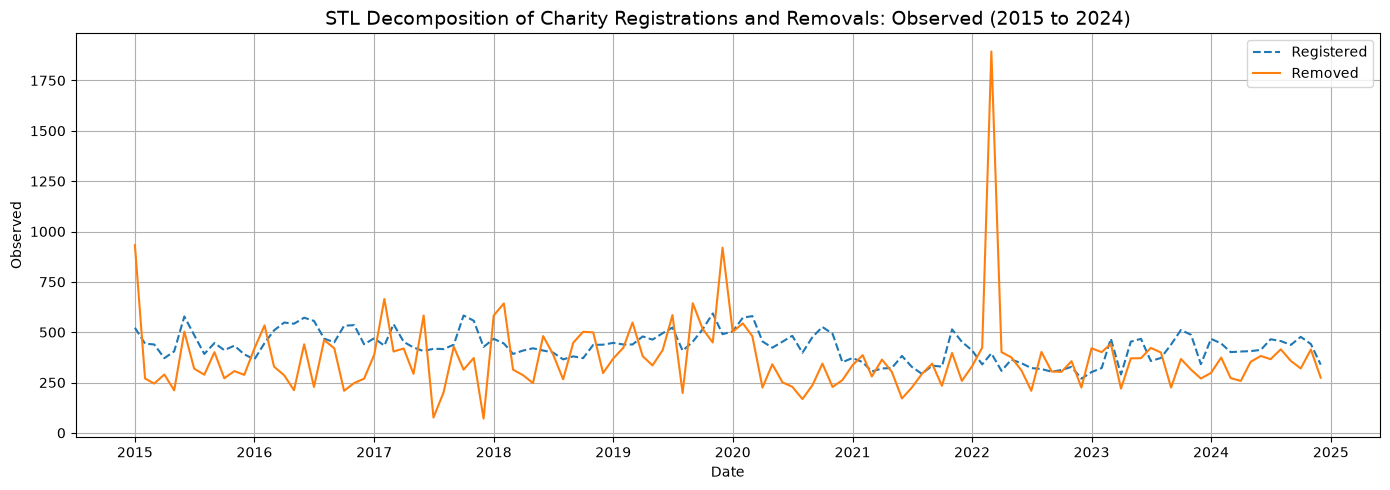

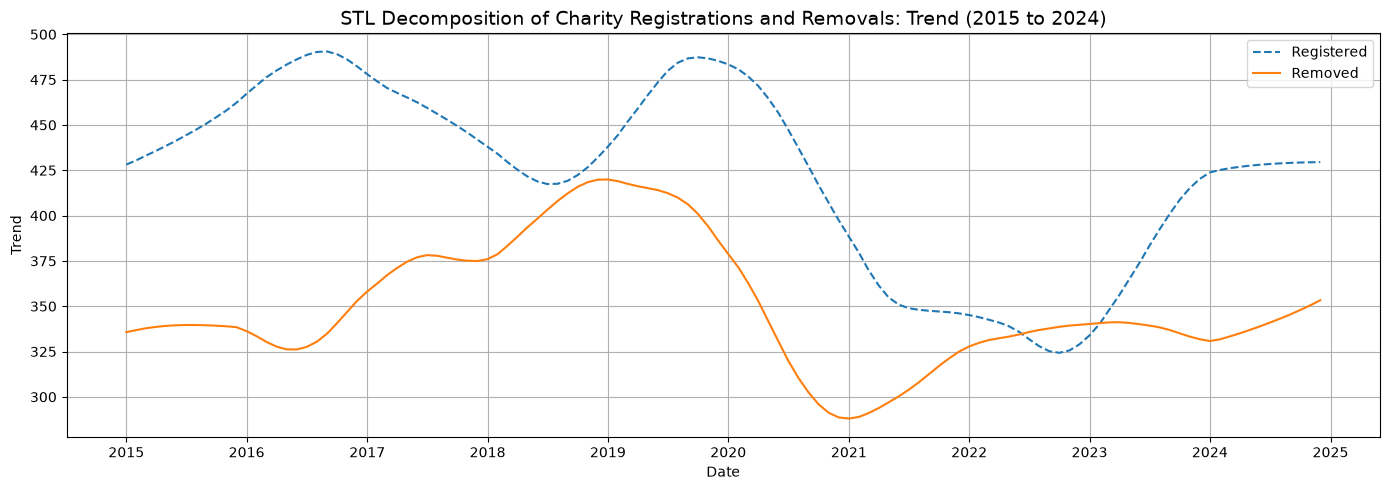

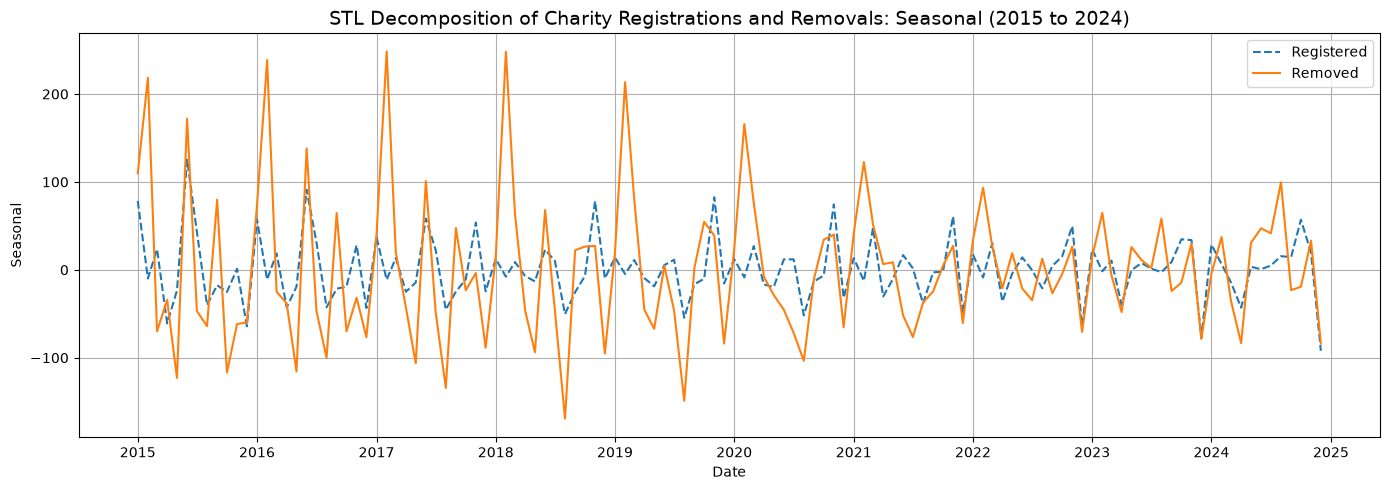

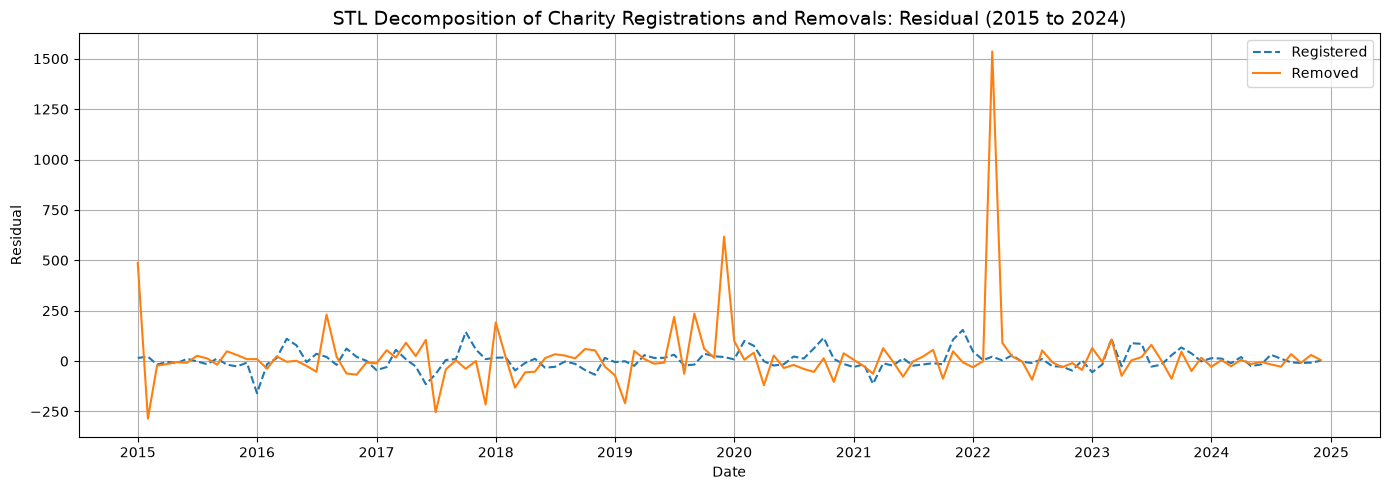

In [5]:
def plot_stl_decomposition(charity: pl.DataFrame):
    monthly_range = pd.date_range(start="2015-01-01", end="2024-12-01", freq="MS")
    monthly_data = charity.with_columns(
        [
            pl.col("date_of_registration").dt.truncate("1mo").alias("reg_month"),
            pl.col("date_of_removal").dt.truncate("1mo").alias("rem_month"),
        ]
    )

    reg_monthly = (
        monthly_data.filter(pl.col("reg_month").is_not_null())
        .group_by("reg_month")
        .len()
        .to_pandas()
        .set_index("reg_month")
    )
    rem_monthly = (
        monthly_data.filter(pl.col("rem_month").is_not_null())
        .group_by("rem_month")
        .len()
        .to_pandas()
        .set_index("rem_month")
    )

    registered_by_month = reg_monthly.reindex(monthly_range, fill_value=0)["len"]
    removed_by_month = rem_monthly.reindex(monthly_range, fill_value=0)["len"]

    def apply_stl(series):
        return STL(series, robust=True).fit()

    stl_reg = apply_stl(registered_by_month)
    stl_rem = apply_stl(removed_by_month)

    components = ["observed", "trend", "seasonal", "resid"]
    titles = ["Observed", "Trend", "Seasonal", "Residual"]
    colors = {"Registered": "#1f77b4", "Removed": "#ff7f0e"}

    for comp, title in zip(components, titles):
        plt.figure(figsize=(14, 5))
        plt.plot(
            getattr(stl_reg, comp),
            label="Registered",
            color=colors["Registered"],
            linestyle="--",
        )
        plt.plot(
            getattr(stl_rem, comp),
            label="Removed",
            color=colors["Removed"],
            linestyle="-",
        )
        plt.title(
            f"STL Decomposition of Charity Registrations and Removals: {title} (2015 to 2024)",
            fontsize=14,
        )
        plt.xlabel("Date")
        plt.ylabel(title)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


plot_stl_decomposition(charity)

## 5. Postcode Analysis


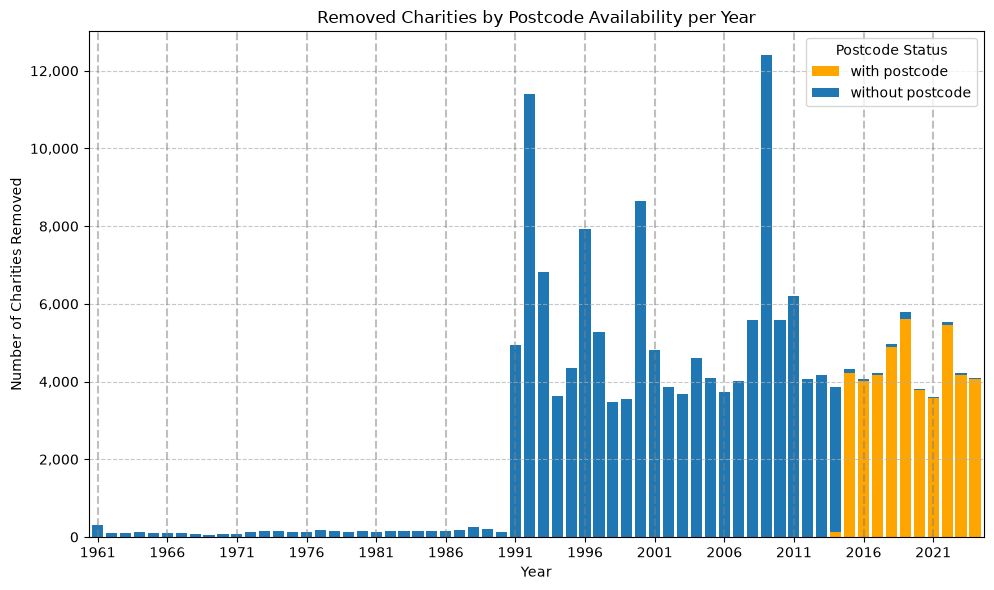

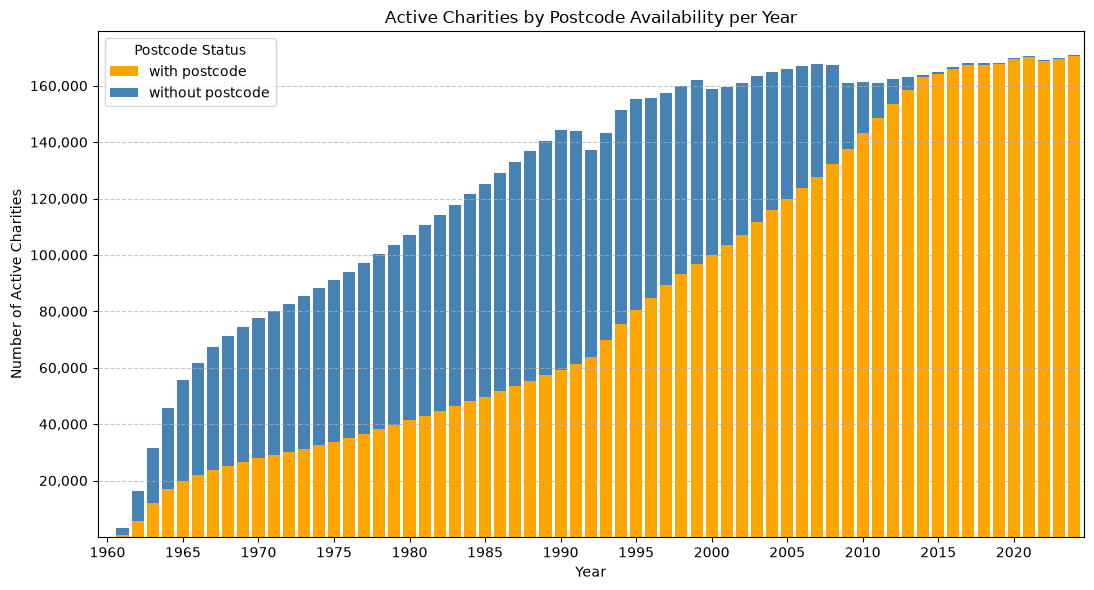

In [6]:
def plot_removed_by_postcode(charity: pl.DataFrame):
    grouped = (
        charity.filter(
            (pl.col("date_of_removal").is_not_null())
            & (pl.col("date_of_removal").dt.year() <= 2024)
        )
        .with_columns(
            removal_year=pl.col("date_of_removal").dt.year(),
            postcode_status=pl.when(pl.col("charity_postcode").is_not_null())
            .then(pl.lit("with postcode"))
            .otherwise(pl.lit("without postcode")),
        )
        .group_by("removal_year", "postcode_status")
        .len()
        .to_pandas()
    )

    removed_by_year_postcode = (
        grouped.pivot(index="removal_year", columns="postcode_status", values="len")
        .fillna(0)
        .sort_index()
    )
    for col in ["with postcode", "without postcode"]:
        if col not in removed_by_year_postcode.columns:
            removed_by_year_postcode[col] = 0

    ax = removed_by_year_postcode[["with postcode", "without postcode"]].plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6),
        color={"with postcode": "orange", "without postcode": "#1f77b4"},
        width=0.8,
    )
    plt.title("Removed Charities by Postcode Availability per Year")
    plt.xlabel("Year")
    plt.ylabel("Number of Charities Removed")
    years = removed_by_year_postcode.index
    show_ticks = [i for i, y in enumerate(years) if (y - years.min()) % 5 == 0]
    ax.set_xticks(show_ticks)
    ax.set_xticklabels([years[i] for i in show_ticks], rotation=0)
    for pos in show_ticks:
        ax.axvline(x=pos, color="grey", linestyle="--", alpha=0.5)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend(title="Postcode Status")
    plt.tight_layout()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.show()


def plot_active_by_postcode(charity: pl.DataFrame):
    charity_processed = charity.with_columns(
        [
            pl.when(pl.col("charity_postcode").is_not_null())
            .then(pl.lit("with postcode"))
            .otherwise(pl.lit("without postcode"))
            .alias("postcode_status"),
            pl.col("date_of_registration").dt.year().alias("reg_year"),
            pl.col("date_of_removal").dt.year().alias("rem_year"),
        ]
    )

    min_year_val = charity_processed.select(pl.col("reg_year").min()).item()
    min_year = int(min_year_val) if min_year_val is not None else 2015
    max_year = 2024
    years_list = list(range(min_year, max_year + 1))
    years_df = pl.DataFrame({"year": years_list}, schema={"year": pl.Int32})

    active_counts = (
        charity_processed.select(["reg_year", "rem_year", "postcode_status"])
        .join(years_df, how="cross")
        .filter(
            (pl.col("reg_year") <= pl.col("year"))
            & (pl.col("rem_year").is_null() | (pl.col("rem_year") > pl.col("year")))
        )
        .group_by(["year", "postcode_status"])
        .len()
        .to_pandas()
    )

    if not active_counts.empty:
        active_df = active_counts.pivot(
            index="year", columns="postcode_status", values="len"
        ).fillna(0)
    else:
        active_df = pd.DataFrame(index=years_list)

    for col in ["with postcode", "without postcode"]:
        if col not in active_df.columns:
            active_df[col] = 0
    active_df = active_df.reindex(years_list, fill_value=0)

    ax = active_df[["with postcode", "without postcode"]].plot(
        kind="bar",
        stacked=True,
        color=["orange", "steelblue"],
        figsize=(11, 6),
        width=0.8,
    )
    plt.title("Active Charities by Postcode Availability per Year")
    plt.xlabel("Year")
    plt.ylabel("Number of Active Charities")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend(title="Postcode Status")

    all_years = active_df.index
    show_ticks = [i for i, y in enumerate(all_years) if y % 5 == 0]
    ax.set_xticks(show_ticks)
    ax.set_xticklabels([all_years[i] for i in show_ticks], rotation=0)
    plt.tight_layout()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.show()


plot_removed_by_postcode(charity)
plot_active_by_postcode(charity)

## 6. Missing Size Category Analysis


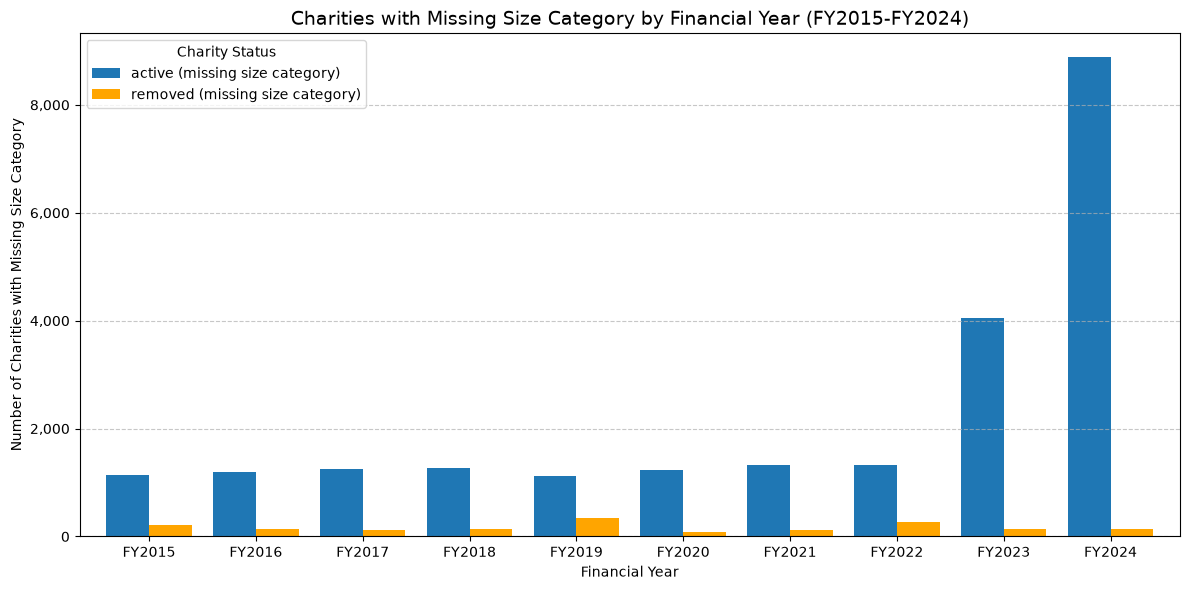

In [7]:
def plot_missing_size_category(charity: pl.DataFrame):
    years = list(range(2015, 2025))
    years_df = pl.DataFrame({"fy": years}, schema={"fy": pl.Int32})

    removed_missing = (
        charity.filter(
            pl.col("removal_fy").is_not_null()
            & pl.col("removal_fy").is_in(years)
            & pl.col("size_category").is_null()
        )
        .group_by("removal_fy")
        .len()
        .to_pandas()
        .set_index("removal_fy")
        .reindex(years, fill_value=0)["len"]
    )

    active_missing = (
        charity.filter(pl.col("size_category").is_null())
        .select(["registration_fy", "removal_fy"])
        .join(years_df, how="cross")
        .filter(
            pl.col("registration_fy").is_not_null()
            & (pl.col("registration_fy") <= pl.col("fy"))
            & (pl.col("removal_fy").is_null() | (pl.col("removal_fy") > pl.col("fy")))
        )
        .group_by("fy")
        .len()
        .to_pandas()
        .set_index("fy")
        .reindex(years, fill_value=0)["len"]
    )

    combined = pd.DataFrame(
        {
            "active (missing size category)": active_missing,
            "removed (missing size category)": removed_missing,
        }
    )
    combined.index = [f"FY{y}" for y in combined.index]

    color_map = {
        "active (missing size category)": "#1f77b4",
        "removed (missing size category)": "orange",
    }
    combined.plot(
        kind="bar",
        figsize=(12, 6),
        color=[color_map[c] for c in combined.columns],
        width=0.8,
    )
    plt.title(
        "Charities with Missing Size Category by Financial Year (FY2015-FY2024)",
        fontsize=14,
    )
    plt.xlabel("Financial Year")
    plt.ylabel("Number of Charities with Missing Size Category")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.xticks(rotation=0)
    plt.gca().yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
    )
    plt.legend(title="Charity Status")
    plt.tight_layout()
    plt.show()


plot_missing_size_category(charity)

## 7. Active Charities and Registration/Removal Rates by Size


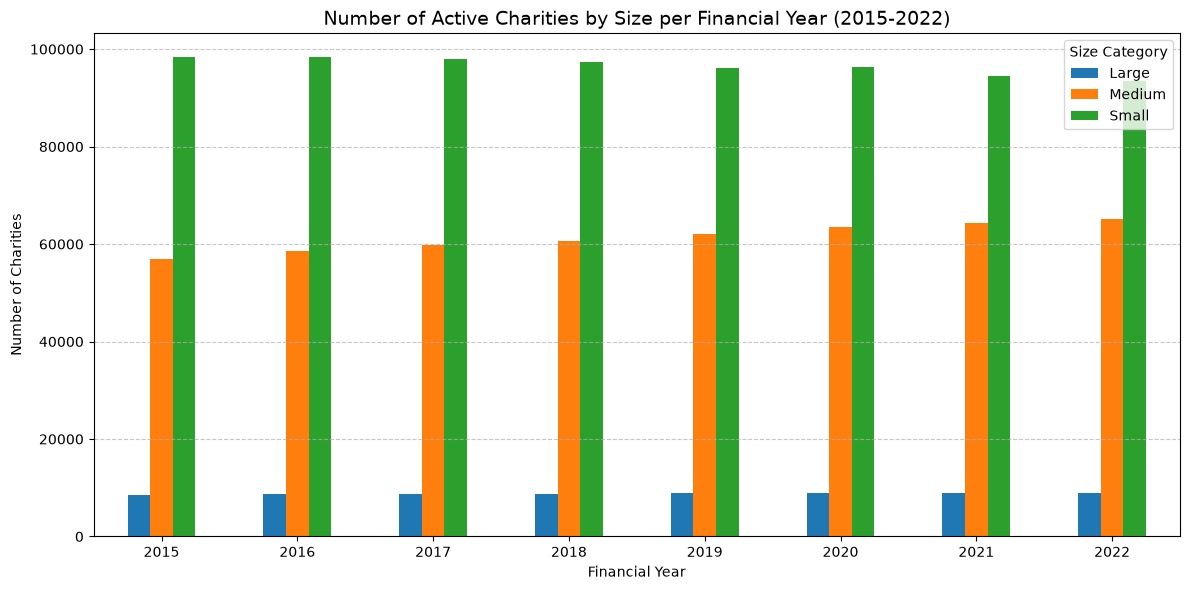

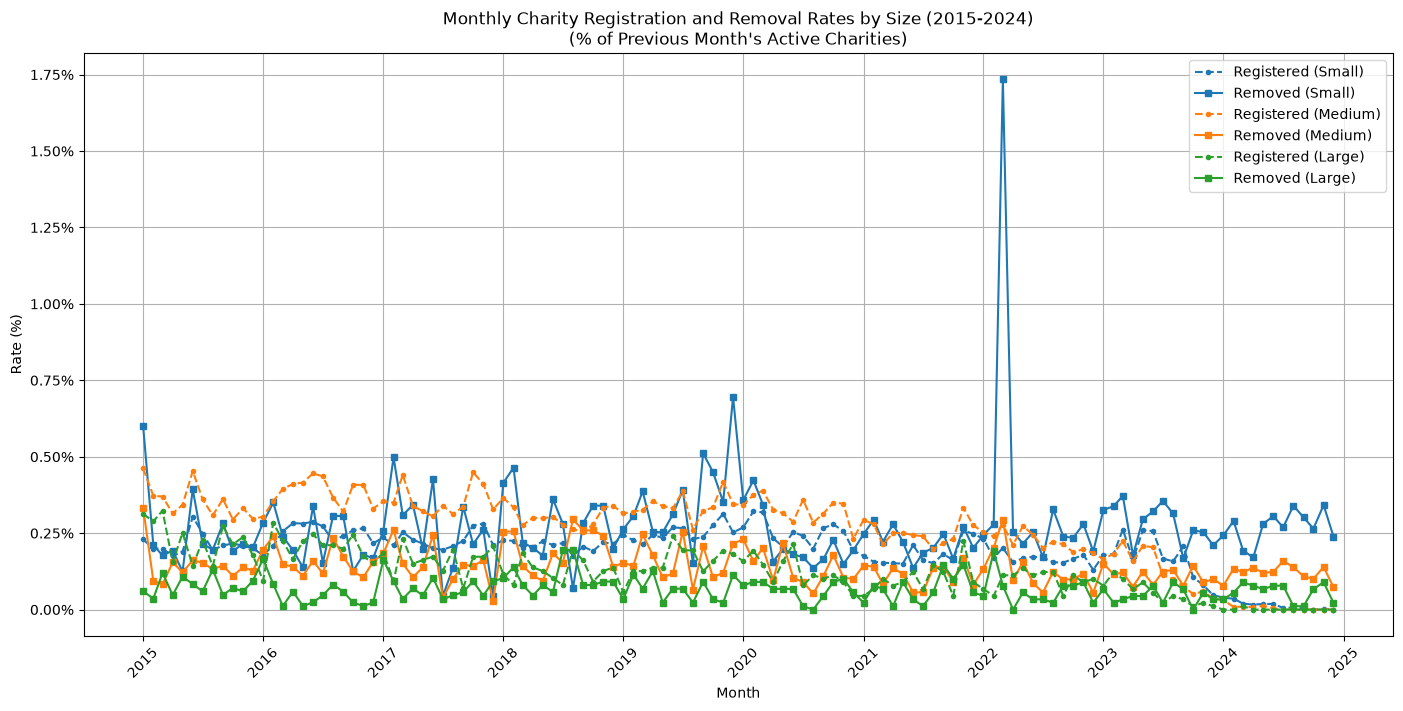

In [8]:
def plot_active_by_size(charity: pl.DataFrame):
    years = list(range(2015, 2023))
    years_df = pl.DataFrame({"fy": years}, schema={"fy": pl.Int32})
    fy_counts = (
        charity.filter(pl.col("size_category").is_not_null())
        .select(["registration_fy", "removal_fy", "size_category"])
        .join(years_df, how="cross")
        .filter(
            pl.col("registration_fy").is_not_null()
            & (pl.col("registration_fy") <= pl.col("fy"))
            & (pl.col("removal_fy").is_null() | (pl.col("removal_fy") > pl.col("fy")))
        )
        .group_by(["fy", "size_category"])
        .len()
        .to_pandas()
        .pivot(index="fy", columns="size_category", values="len")
        .fillna(0)
    )
    if set(["Large", "Medium", "Small"]).issubset(fy_counts.columns):
        fy_counts = fy_counts[["Large", "Medium", "Small"]]
    fy_counts.plot(kind="bar", figsize=(12, 6), color=["#1f77b4", "#ff7f0e", "#2ca02c"])
    plt.title(
        "Number of Active Charities by Size per Financial Year (2015-2022)", fontsize=14
    )
    plt.xlabel("Financial Year")
    plt.ylabel("Number of Charities")
    plt.xticks(rotation=0)
    plt.legend(title="Size Category")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_monthly_rates_by_size(charity: pl.DataFrame):
    starts = list(pd.date_range("2014-12-01", "2024-12-01", freq="MS").date)
    df = charity.select(
        [
            pl.col("date_of_registration").dt.truncate("1mo").alias("reg_month"),
            pl.col("date_of_removal").dt.truncate("1mo").alias("rem_month"),
            pl.col("size_category"),
        ]
    ).filter(pl.col("size_category").is_not_null())
    months_df = pl.DataFrame({"month": starts}, schema={"month": pl.Date})

    active_counts = (
        df.join(months_df, how="cross")
        .filter(
            (pl.col("reg_month") <= pl.col("month"))
            & (pl.col("rem_month").is_null() | (pl.col("rem_month") > pl.col("month")))
        )
        .group_by(["month", "size_category"])
        .len()
        .to_pandas()
        .pivot(index="month", columns="size_category", values="len")
        .fillna(0)
    )
    reg_counts = (
        df.filter(pl.col("reg_month").is_in(starts))
        .group_by(["reg_month", "size_category"])
        .len()
        .to_pandas()
        .pivot(index="reg_month", columns="size_category", values="len")
        .fillna(0)
        .reindex(starts, fill_value=0)
    )
    rem_counts = (
        df.filter(pl.col("rem_month").is_in(starts))
        .group_by(["rem_month", "size_category"])
        .len()
        .to_pandas()
        .pivot(index="rem_month", columns="size_category", values="len")
        .fillna(0)
        .reindex(starts, fill_value=0)
    )

    prev_active = active_counts.shift(1)
    reg_pct = (reg_counts / prev_active * 100).loc[pd.Timestamp("2015-01-01").date() :]
    rem_pct = (rem_counts / prev_active * 100).loc[pd.Timestamp("2015-01-01").date() :]
    reg_pct.index = pd.to_datetime(reg_pct.index)
    rem_pct.index = pd.to_datetime(rem_pct.index)

    plt.figure(figsize=(14, 7))
    colors = {"Small": "tab:blue", "Medium": "tab:orange", "Large": "tab:green"}
    for size in ["Small", "Medium", "Large"]:
        if size in reg_pct.columns:
            plt.plot(
                reg_pct.index,
                reg_pct[size],
                linestyle="--",
                marker="o",
                markersize=3,
                color=colors[size],
                label=f"Registered ({size})",
            )
        if size in rem_pct.columns:
            plt.plot(
                rem_pct.index,
                rem_pct[size],
                linestyle="-",
                marker="s",
                markersize=4,
                color=colors[size],
                label=f"Removed ({size})",
            )
    plt.title(
        "Monthly Charity Registration and Removal Rates by Size (2015-2024)\n(% of Previous Month's Active Charities)"
    )
    plt.xlabel("Month")
    plt.ylabel("Rate (%)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter())
    plt.show()


plot_active_by_size(charity)
plot_monthly_rates_by_size(charity)

## 8. Removal Analysis by Age and Size


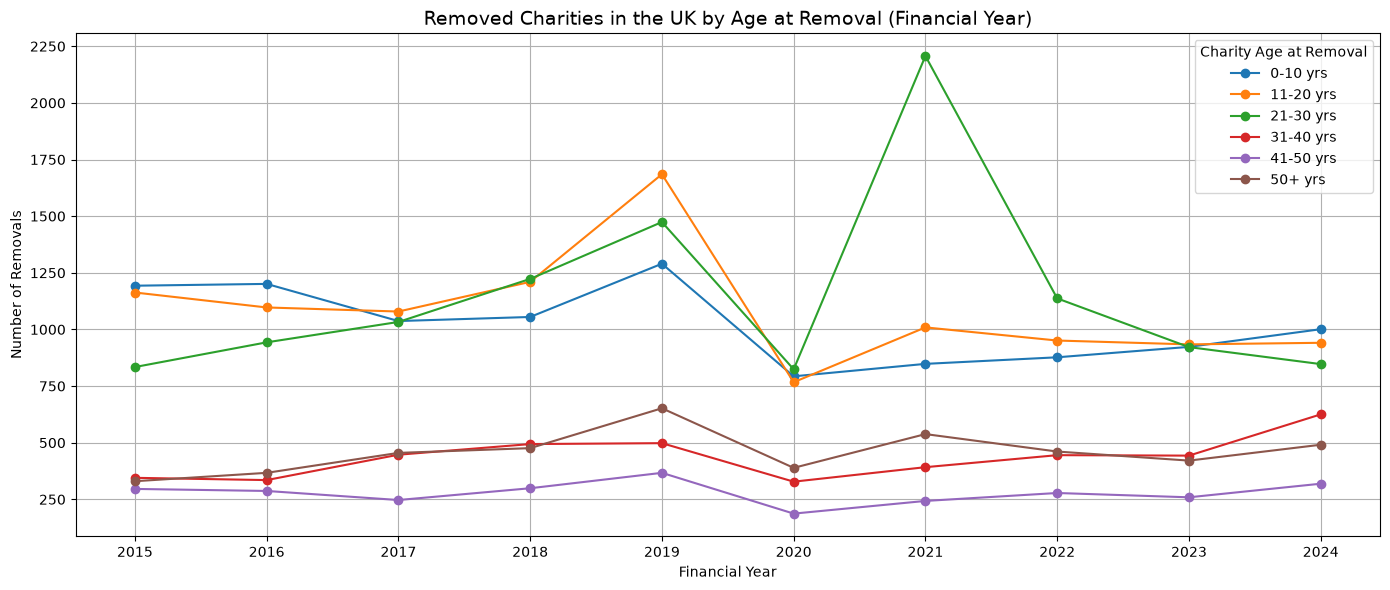

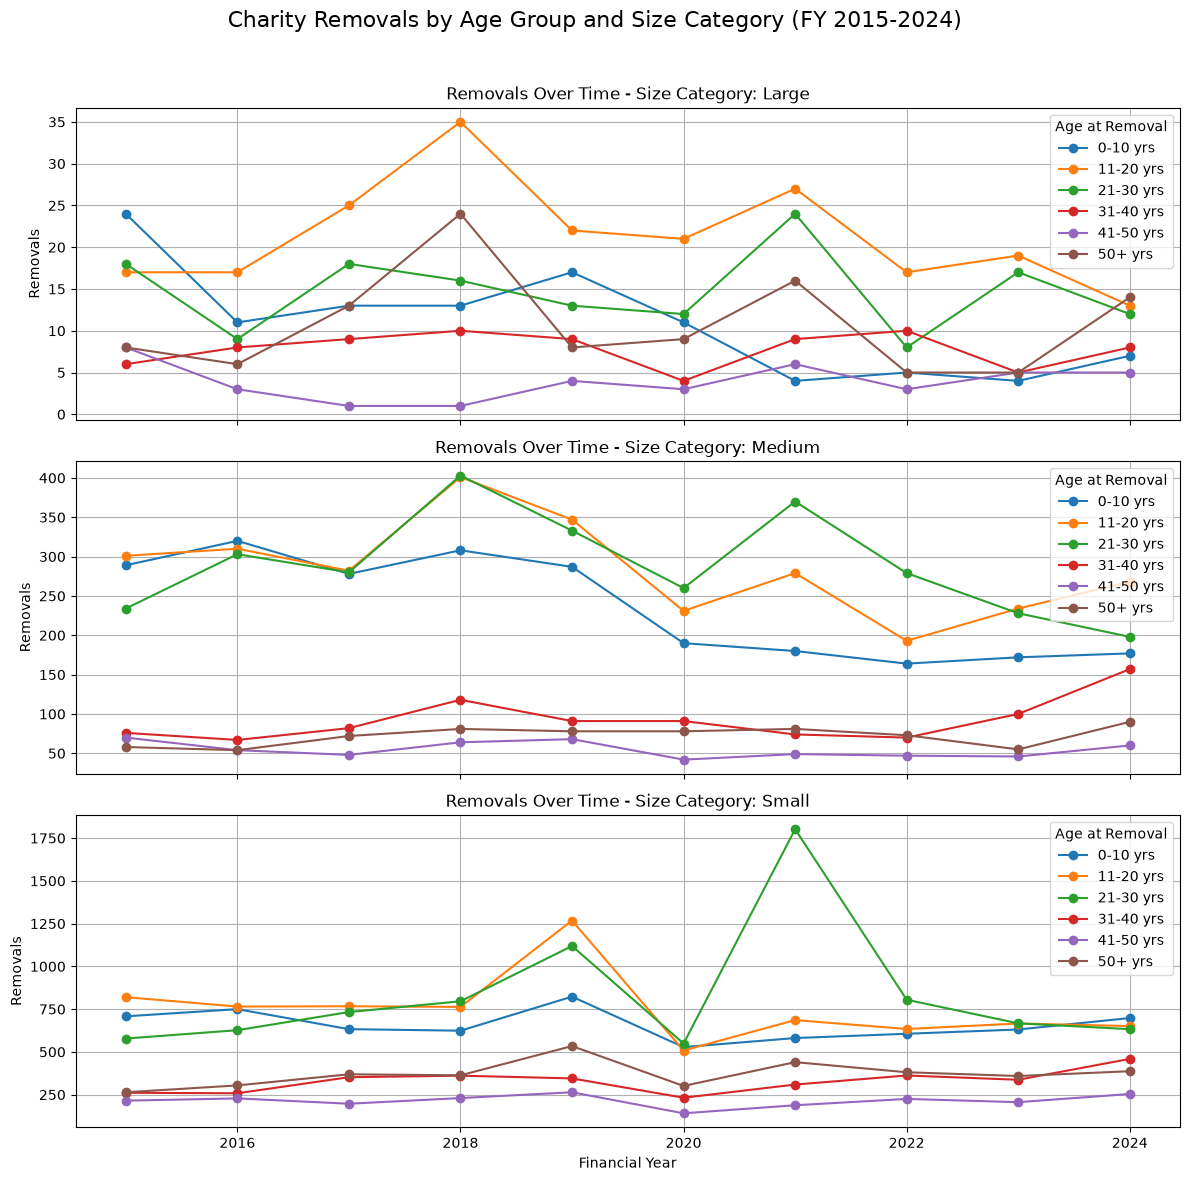

In [9]:
def plot_removals_by_age_and_size(charity: pl.DataFrame):
    df = (
        charity.filter(
            pl.col("removal_fy").is_between(2015, 2024)
            & pl.col("date_of_removal").is_not_null()
            & pl.col("date_of_registration").is_not_null()
        )
        .with_columns(
            pl.col("date_of_removal")
            .sub(pl.col("date_of_registration"))
            .dt.total_days()
            .floordiv(365)
            .alias("age_at_removal")
        )
        .filter(pl.col("age_at_removal") >= 0)
        .with_columns(
            pl.when(pl.col("age_at_removal") < 10)
            .then(pl.lit("0-10 yrs"))
            .when(pl.col("age_at_removal") < 20)
            .then(pl.lit("11-20 yrs"))
            .when(pl.col("age_at_removal") < 30)
            .then(pl.lit("21-30 yrs"))
            .when(pl.col("age_at_removal") < 40)
            .then(pl.lit("31-40 yrs"))
            .when(pl.col("age_at_removal") < 50)
            .then(pl.lit("41-50 yrs"))
            .otherwise(pl.lit("50+ yrs"))
            .alias("removal_age_group")
        )
    )

    # 1. Total removals by age
    removals_by_age_fy = (
        df.group_by(["removal_fy", "removal_age_group"])
        .len()
        .to_pandas()
        .pivot(index="removal_fy", columns="removal_age_group", values="len")
        .fillna(0)
        .sort_index()
    )
    labels = ["0-10 yrs", "11-20 yrs", "21-30 yrs", "31-40 yrs", "41-50 yrs", "50+ yrs"]
    available_labels = [
        label for label in labels if label in removals_by_age_fy.columns
    ]
    removals_by_age_fy = removals_by_age_fy[available_labels]

    plt.figure(figsize=(14, 6))
    for col in removals_by_age_fy.columns:
        plt.plot(
            removals_by_age_fy.index, removals_by_age_fy[col], marker="o", label=col
        )
    plt.title(
        "Removed Charities in the UK by Age at Removal (Financial Year)", fontsize=14
    )
    plt.xlabel("Financial Year")
    plt.ylabel("Number of Removals")
    plt.legend(title="Charity Age at Removal")
    plt.grid(True)
    plt.tight_layout()
    plt.xticks(removals_by_age_fy.index)
    plt.show()

    # 2. Removals by age group AND size category
    filtered = df.filter(pl.col("size_category").is_not_null())
    pivoted = (
        filtered.group_by(["removal_fy", "size_category", "removal_age_group"])
        .len()
        .to_pandas()
        .pivot_table(
            index="removal_fy",
            columns=["size_category", "removal_age_group"],
            values="len",
            fill_value=0,
        )
    )
    charity_size_categories = pivoted.columns.get_level_values(0).unique()
    fig, axs = plt.subplots(
        len(charity_size_categories), 1, figsize=(12, 4 * len(charity_size_categories)), sharex=True
    )
    if len(charity_size_categories) == 1:
        axs = [axs]
    for i, size in enumerate(charity_size_categories):
        ax = axs[i]
        for age in labels:
            if (size, age) in pivoted.columns:
                ax.plot(pivoted.index, pivoted[size, age], marker="o", label=age)
        ax.set_title(f"Removals Over Time - Size Category: {size}")
        ax.set_ylabel("Removals")
        ax.legend(title="Age at Removal")
        ax.grid(True)
    axs[-1].set_xlabel("Financial Year")
    plt.suptitle(
        "Charity Removals by Age Group and Size Category (FY 2015-2024)", fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


plot_removals_by_age_and_size(charity)

## 9. Classification Analysis


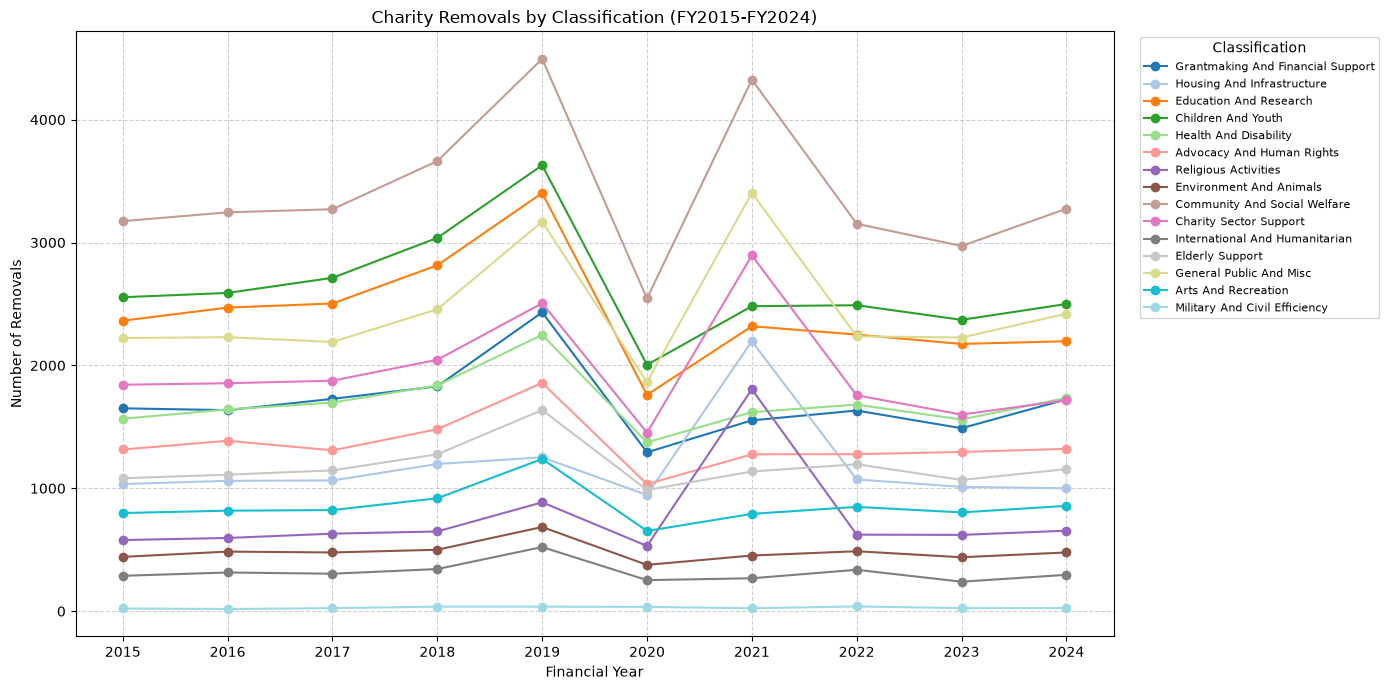

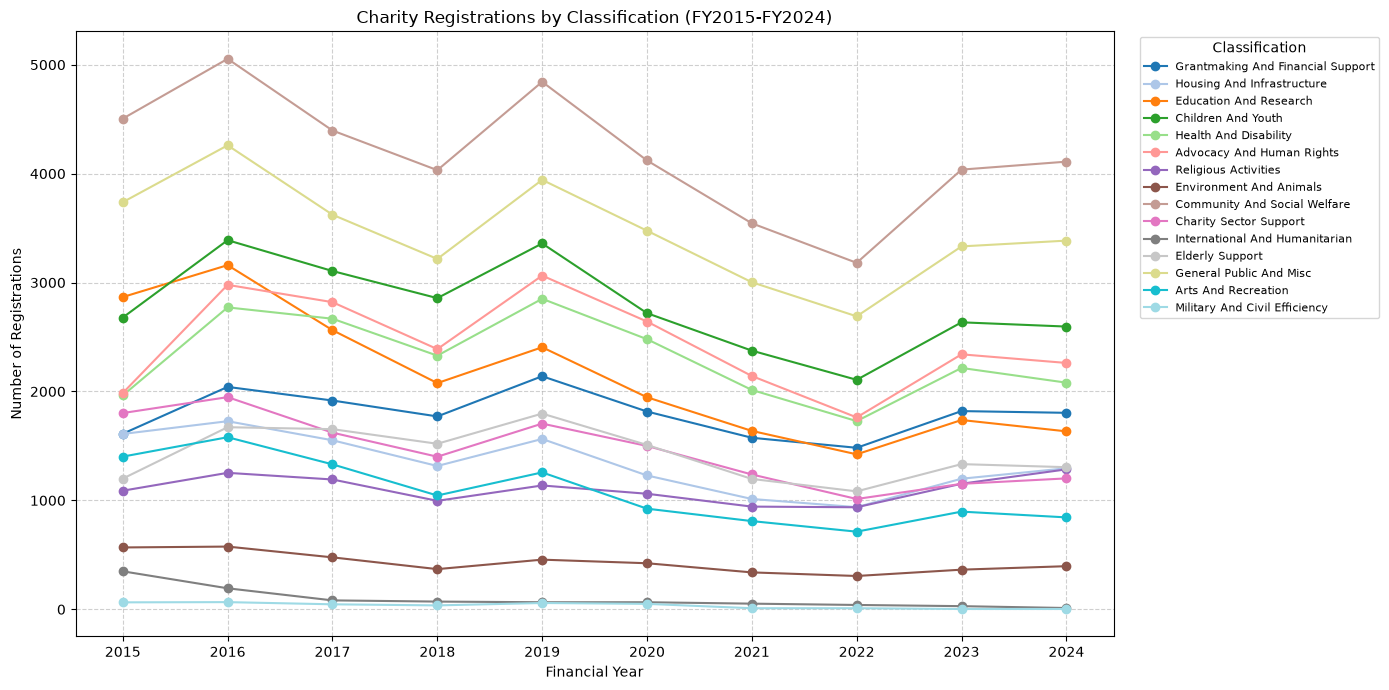

In [10]:
def plot_classification_analysis(charity: pl.DataFrame):
    class_cols = [c for c in CATEGORY_MAPPING.keys() if c in charity.columns]

    if not class_cols:
        print("-------------")
        print("WARNING: No classification columns found in the `charity` variable!")
        print(
            "Please restart the kernel and rerun the first cell to reload the prepared charity register."
        )
        print("-------------")
        return

    aggs = [pl.col(c).cast(pl.Int32).sum().alias(c) for c in class_cols]

    # 1. Removals by classification
    filtered_rem = charity.filter(pl.col("removal_fy").is_between(2015, 2024))
    summary_rem = (
        filtered_rem.group_by("removal_fy")
        .agg(aggs)
        .to_pandas()
        .set_index("removal_fy")
        .reindex(range(2015, 2025), fill_value=0)
    )

    cmap_rem = plt.get_cmap("tab20", len(summary_rem.columns))
    plt.figure(figsize=(14, 7))
    for i, col in enumerate(summary_rem.columns):
        plt.plot(
            summary_rem.index,
            summary_rem[col],
            marker="o",
            linewidth=1.5,
            label=col.replace("_", " "),
            color=cmap_rem(i),
        )
    plt.title("Charity Removals by Classification (FY2015-FY2024)")
    plt.xlabel("Financial Year")
    plt.ylabel("Number of Removals")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.xticks(summary_rem.index)
    plt.legend(
        title="Classification", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8
    )
    plt.tight_layout()
    plt.show()

    # 2. Registrations by classification
    filtered_reg = charity.filter(pl.col("registration_fy").is_between(2015, 2024))
    summary_reg = (
        filtered_reg.group_by("registration_fy")
        .agg(aggs)
        .to_pandas()
        .set_index("registration_fy")
        .reindex(range(2015, 2025), fill_value=0)
    )

    plt.figure(figsize=(14, 7))
    for i, col in enumerate(summary_reg.columns):
        plt.plot(
            summary_reg.index,
            summary_reg[col],
            marker="o",
            linewidth=1.5,
            label=col.replace("_", " "),
            color=cmap_rem(i),
        )
    plt.title("Charity Registrations by Classification (FY2015-FY2024)")
    plt.xlabel("Financial Year")
    plt.ylabel("Number of Registrations")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.xticks(summary_reg.index)
    plt.legend(
        title="Classification", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8
    )
    plt.tight_layout()
    plt.show()


plot_classification_analysis(charity)

## 10. Classification grouped by Size


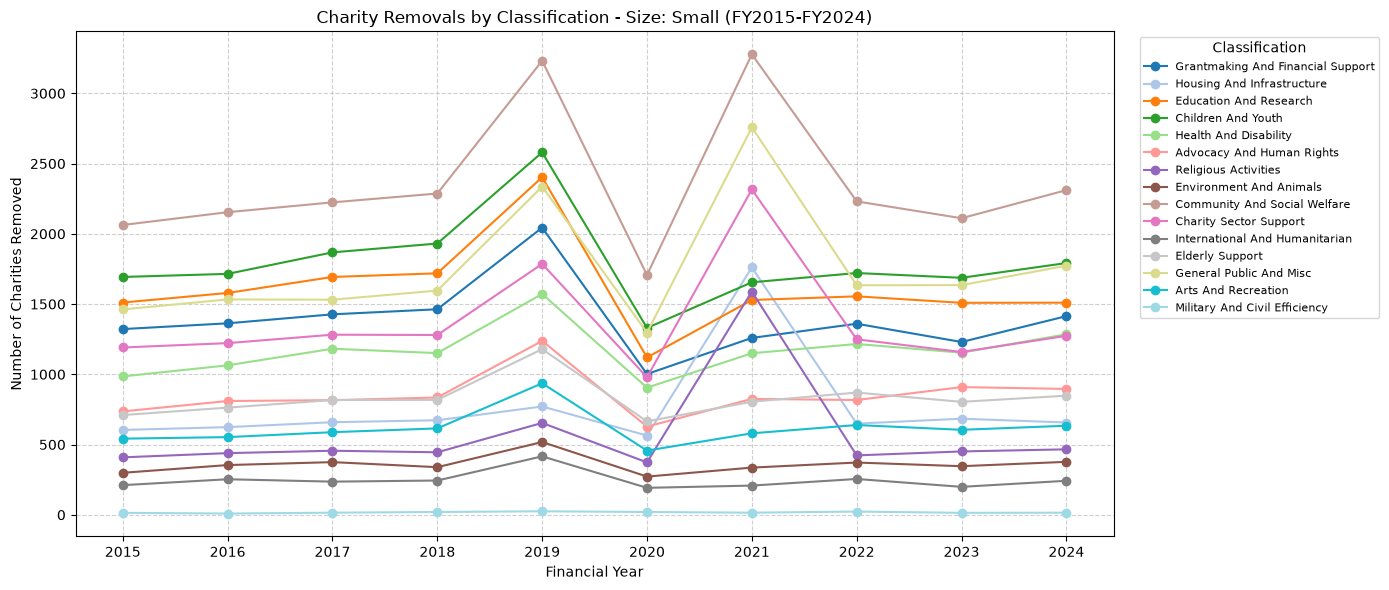

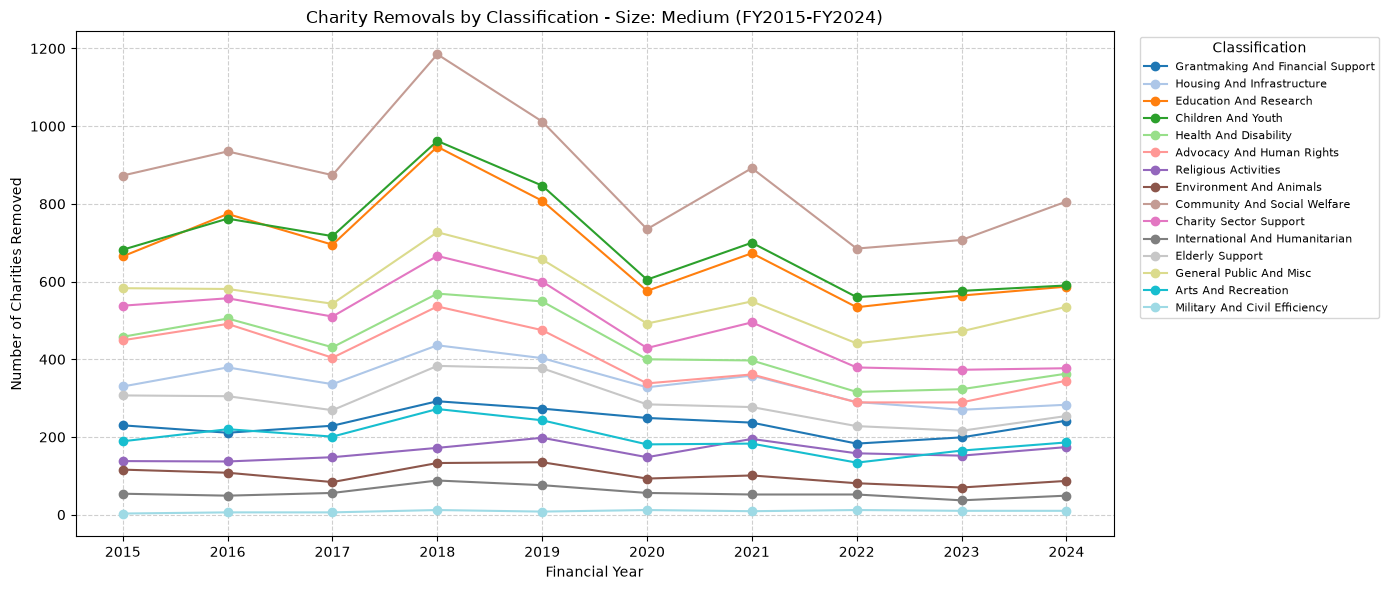

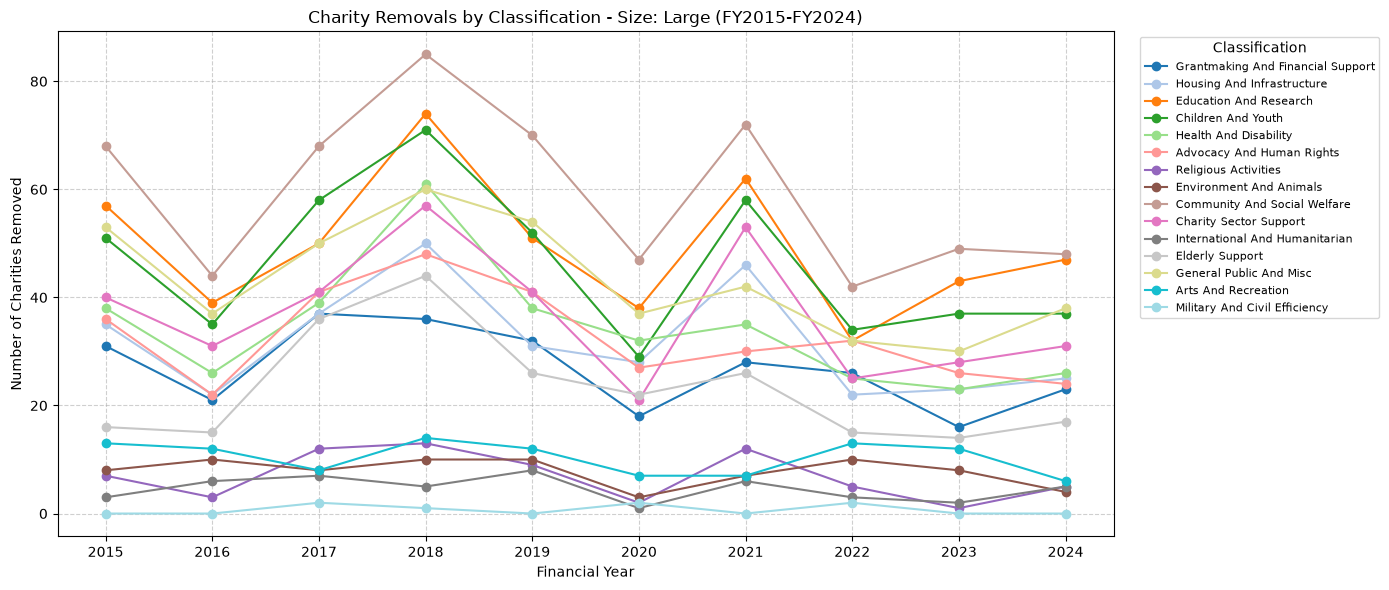

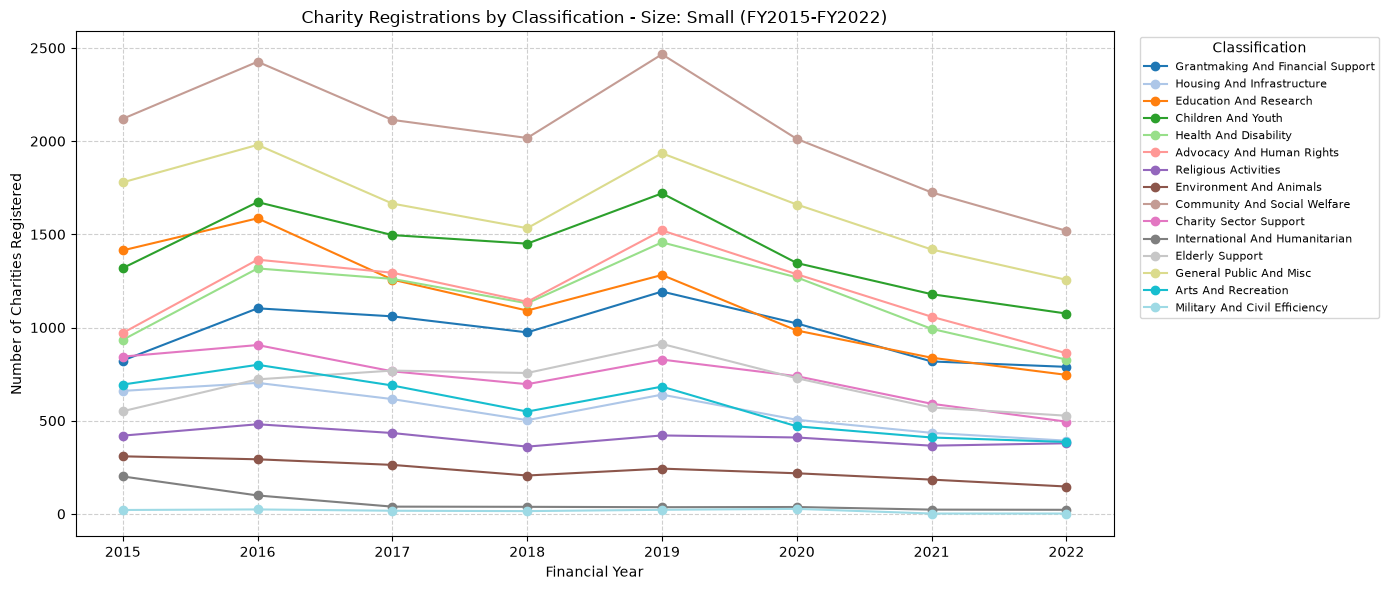

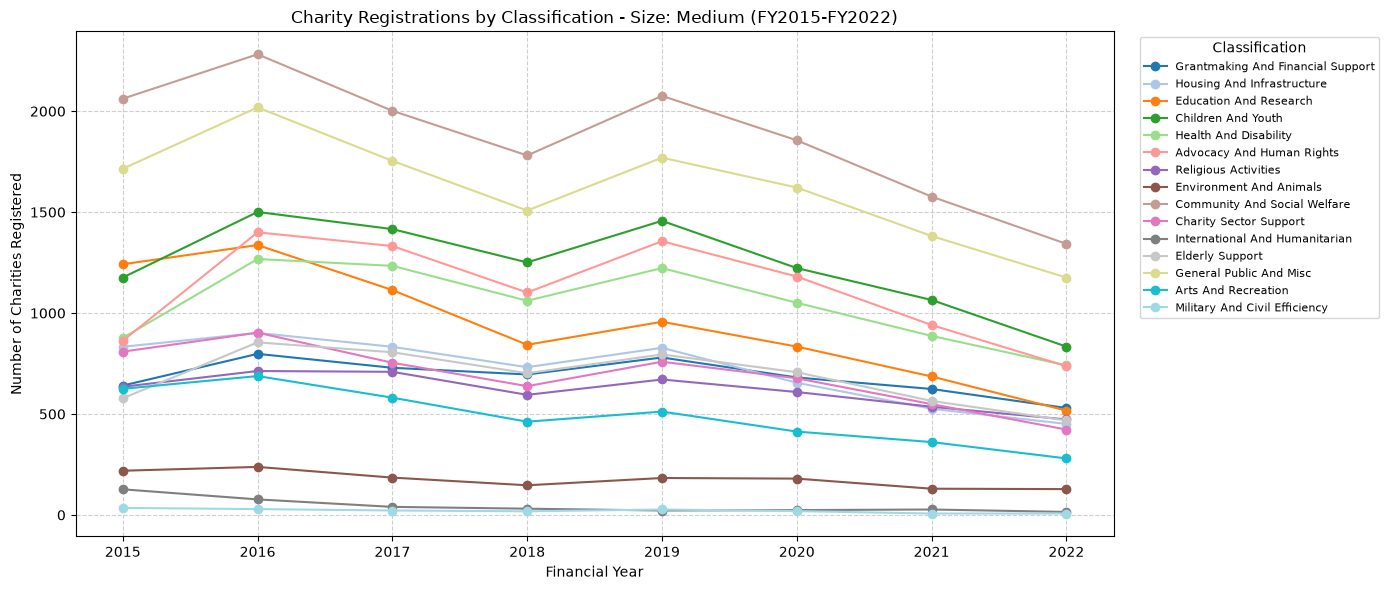

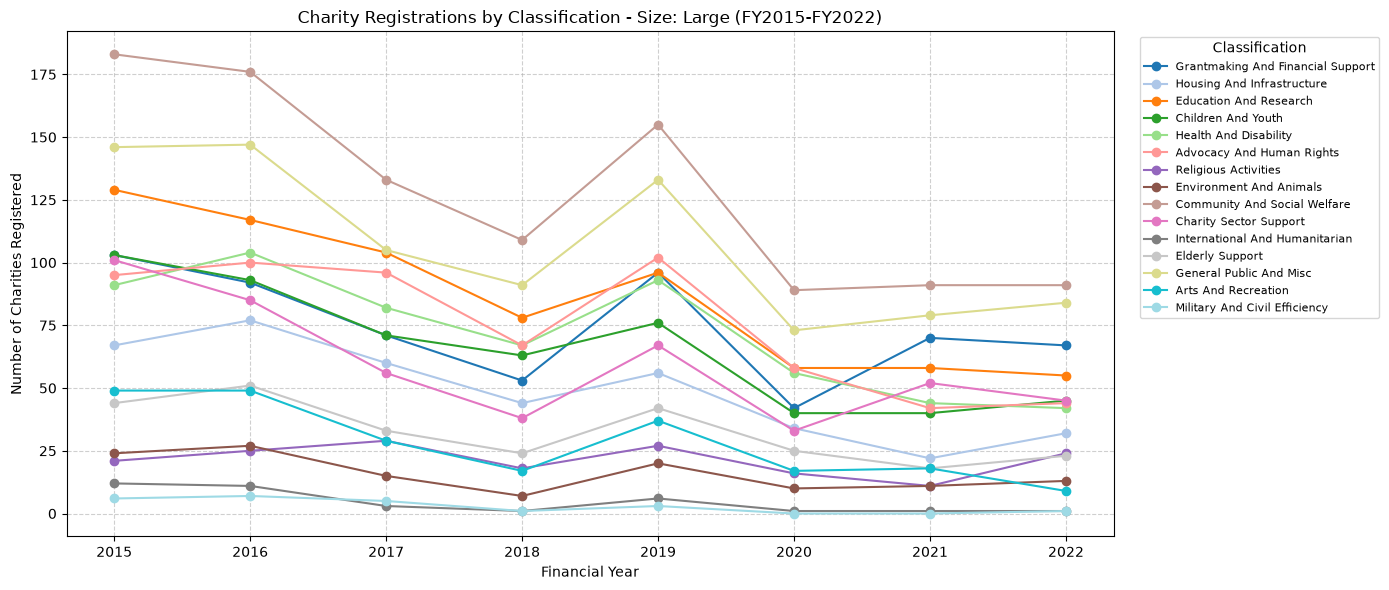

In [11]:
def plot_classification_by_size(charity: pl.DataFrame):
    class_cols = [c for c in CATEGORY_MAPPING.keys() if c in charity.columns]

    if not class_cols:
        print("WARNING: Restart the kernel and rerun the first cell.")
        return
    aggs = [pl.col(c).cast(pl.Int32).sum().alias(c) for c in class_cols]

    # 1. Removals by classification and size
    for size in ["Small", "Medium", "Large"]:
        subset = charity.filter(
            pl.col("removal_fy").is_between(2015, 2024)
            & (pl.col("size_category") == size)
        )
        summary = (
            subset.group_by("removal_fy")
            .agg(aggs)
            .to_pandas()
            .set_index("removal_fy")
            .reindex(range(2015, 2025), fill_value=0)
        )

        num_series = len(summary.columns)
        cmap = plt.get_cmap("tab20" if num_series <= 20 else "hsv", num_series)
        plt.figure(figsize=(14, 6))
        for i, col in enumerate(summary.columns):
            plt.plot(
                summary.index,
                summary[col],
                marker="o",
                linewidth=1.5,
                label=col.replace("_", " "),
                color=cmap(i),
            )
        plt.title(f"Charity Removals by Classification - Size: {size} (FY2015-FY2024)")
        plt.xlabel("Financial Year")
        plt.ylabel("Number of Charities Removed")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.xticks(list(range(2015, 2025)))
        plt.legend(
            title="Classification",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=8,
        )
        plt.tight_layout()
        plt.show()

    # 2. Registrations by classification and size
    for size in ["Small", "Medium", "Large"]:
        subset = charity.filter(
            pl.col("registration_fy").is_between(2015, 2022)
            & (pl.col("size_category") == size)
        )
        summary = (
            subset.group_by("registration_fy")
            .agg(aggs)
            .to_pandas()
            .set_index("registration_fy")
            .reindex(range(2015, 2023), fill_value=0)
        )

        num_series = len(summary.columns)
        cmap = plt.get_cmap("tab20" if num_series <= 20 else "hsv", num_series)
        plt.figure(figsize=(14, 6))
        for i, col in enumerate(summary.columns):
            plt.plot(
                summary.index,
                summary[col],
                marker="o",
                linewidth=1.5,
                label=col.replace("_", " "),
                color=cmap(i),
            )
        plt.title(
            f"Charity Registrations by Classification - Size: {size} (FY2015-FY2022)"
        )
        plt.xlabel("Financial Year")
        plt.ylabel("Number of Charities Registered")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.xticks(list(range(2015, 2023)))
        plt.legend(
            title="Classification",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=8,
        )
        plt.tight_layout()
        plt.show()


plot_classification_by_size(charity)

## 11. Removal Rate Analysis by Land Ownership


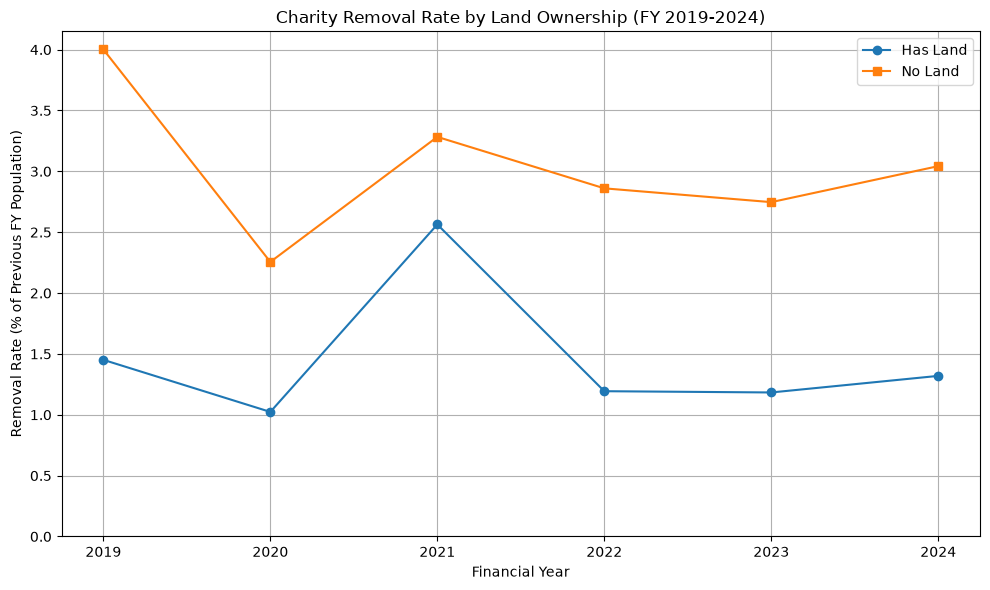

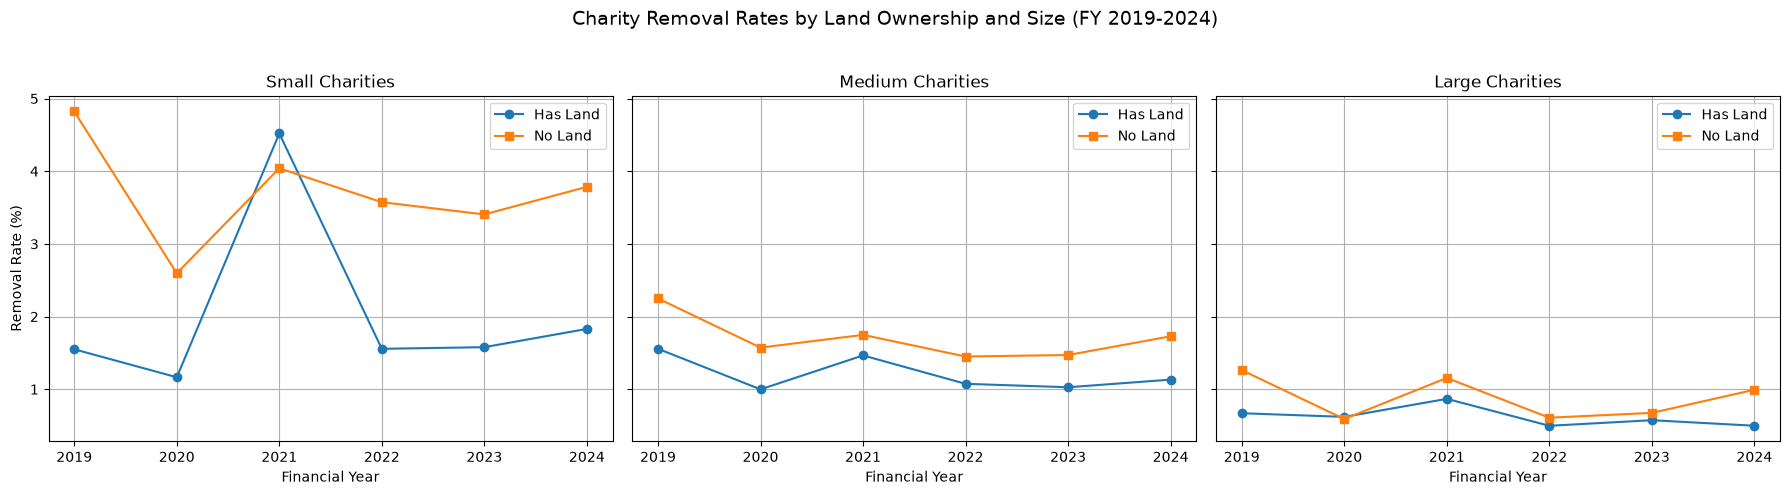

In [12]:
def plot_removal_by_land_ownership(charity: pl.DataFrame):
    df = charity.filter(pl.col("charity_has_land").is_not_null())
    fys = list(range(2019, 2025))
    years_df = pl.DataFrame({"fy": fys}, schema={"fy": pl.Int32})

    # Active
    active = (
        df.join(years_df, how="cross")
        .filter(
            (pl.col("registration_fy") <= pl.col("fy") - 1)
            & (
                pl.col("removal_fy").is_null()
                | (pl.col("removal_fy") > pl.col("fy") - 1)
            )
        )
        .group_by(["fy", "charity_has_land"])
        .agg(pl.len().alias("active"))
    )

    # Removed
    removed = (
        df.join(years_df, how="cross")
        .filter(pl.col("removal_fy") == pl.col("fy"))
        .group_by(["fy", "charity_has_land"])
        .agg(pl.len().alias("removed"))
    )

    rates = (
        active.join(removed, on=["fy", "charity_has_land"], how="left")
        .fill_null(0)
        .with_columns((pl.col("removed") / pl.col("active") * 100).alias("rate"))
        .to_pandas()
    )
    plt.figure(figsize=(10, 6))
    with_land = rates[rates["charity_has_land"] == True].set_index("fy").sort_index()
    without_land = (
        rates[rates["charity_has_land"] == False].set_index("fy").sort_index()
    )
    plt.plot(with_land.index, with_land["rate"], marker="o", label="Has Land")
    plt.plot(without_land.index, without_land["rate"], marker="s", label="No Land")
    plt.title("Charity Removal Rate by Land Ownership (FY 2019-2024)")
    plt.xlabel("Financial Year")
    plt.ylabel("Removal Rate (% of Previous FY Population)")
    plt.legend()
    plt.grid(True)
    plt.xticks(fys)
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()

    # Same grouped by Size Category
    filtered = df.filter(pl.col("size_category").is_not_null())
    active_sz = (
        filtered.join(years_df, how="cross")
        .filter(
            (pl.col("registration_fy") <= pl.col("fy") - 1)
            & (
                pl.col("removal_fy").is_null()
                | (pl.col("removal_fy") > pl.col("fy") - 1)
            )
        )
        .group_by(["fy", "size_category", "charity_has_land"])
        .agg(pl.len().alias("active"))
    )
    removed_sz = (
        filtered.join(years_df, how="cross")
        .filter(pl.col("removal_fy") == pl.col("fy"))
        .group_by(["fy", "size_category", "charity_has_land"])
        .agg(pl.len().alias("removed"))
    )
    rates_sz = (
        active_sz.join(
            removed_sz, on=["fy", "size_category", "charity_has_land"], how="left"
        )
        .fill_null(0)
        .with_columns((pl.col("removed") / pl.col("active") * 100).alias("rate"))
        .to_pandas()
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for i, size in enumerate(["Small", "Medium", "Large"]):
        ax = axes[i]
        size_data = rates_sz[rates_sz["size_category"] == size]
        with_land = (
            size_data[size_data["charity_has_land"] == True]
            .set_index("fy")
            .sort_index()
        )
        wo_land = (
            size_data[size_data["charity_has_land"] == False]
            .set_index("fy")
            .sort_index()
        )
        ax.plot(with_land.index, with_land["rate"], marker="o", label="Has Land")
        ax.plot(wo_land.index, wo_land["rate"], marker="s", label="No Land")
        ax.set_title(f"{size} Charities")
        ax.set_xlabel("Financial Year")
        if i == 0:
            ax.set_ylabel("Removal Rate (%)")
        ax.set_xticks(fys)
        ax.grid(True)
        ax.legend()
    plt.suptitle(
        "Charity Removal Rates by Land Ownership and Size (FY 2019-2024)", fontsize=14
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


plot_removal_by_land_ownership(charity)